# CIELAB Color Distribution

Visualizes the distribution of extracted lipstick colors across the CIELAB color space.

- **a\*–b\* scatter**: chromatic plane: warm/cool and pink/orange/brown axes
- **L\* distribution**: lightness spread across the dataset
- **Facet by format**: whether swatch / bullet / liquid / other cluster differently
- **Color group centroids**: the 25 GMM groups overlaid on the scatter

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='white', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [2]:
CSV = Path('../data/processed/products_pipeline.csv')
df  = pd.read_csv(CSV)

# Drop rows with missing LAB values
df = df.dropna(subset=['L', 'a', 'b', 'hex_color']).copy()

# Normalize hex to lowercase with leading #
df['hex_color'] = df['hex_color'].str.strip().str.lower()
df['hex_color'] = df['hex_color'].apply(lambda x: x if x.startswith('#') else f'#{x}')
df['group_hex'] = df['group_hex'].str.strip().str.lower()
df['group_hex'] = df['group_hex'].apply(lambda x: x if x.startswith('#') else f'#{x}')

print(f'{len(df):,} products loaded')
print(f'pred_label counts:\n{df["pred_label"].value_counts()}')

8,200 products loaded
pred_label counts:
pred_label
swatch    3682
bullet    2852
liquid    1176
pencil     234
closed     216
lips        40
Name: count, dtype: int64


## a\*–b\* scatter: full dataset

Each point is one product shade, colored by its extracted hex. The a\* axis runs green (–) to red/pink (+); b\* runs blue (–) to yellow/orange (+). Most lipstick shades cluster in the warm positive quadrant.

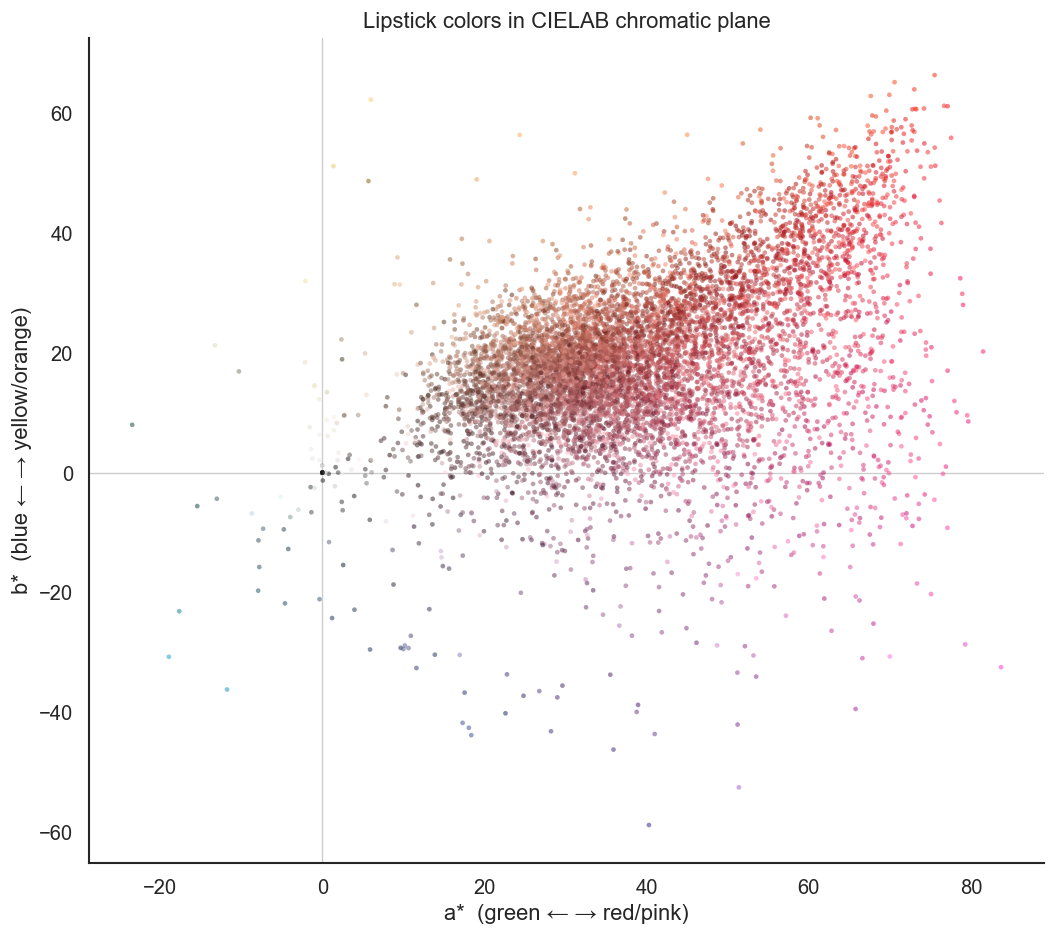

In [3]:
fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(
    df['a'], df['b'],
    c=df['hex_color'],
    s=8, alpha=0.5, linewidths=0
)

ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
ax.set_xlabel('a*  (green ← → red/pink)')
ax.set_ylabel('b*  (blue ← → yellow/orange)')
ax.set_title('Lipstick colors in CIELAB chromatic plane')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## L\* distribution

Lightness across the full dataset. Lipsticks typically range from deep plums (L~20) to pale nudes (L~80).

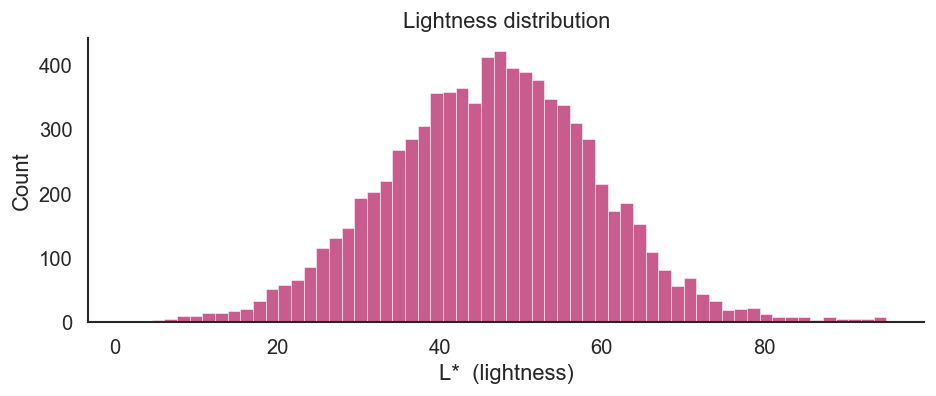

count    8200.0
mean       46.5
std        13.0
min         1.4
25%        37.8
50%        46.7
75%        55.0
max        95.1
Name: L, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.hist(df['L'], bins=60, color='#c85c8e', edgecolor='white', linewidth=0.3)
ax.set_xlabel('L*  (lightness)')
ax.set_ylabel('Count')
ax.set_title('Lightness distribution')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(df['L'].describe().round(1))

## a\*–b\* scatter: faceted by format

Checks whether different product formats (swatch, bullet, liquid, other) land in different parts of the chromatic plane: which would suggest extraction bias rather than actual color differences.

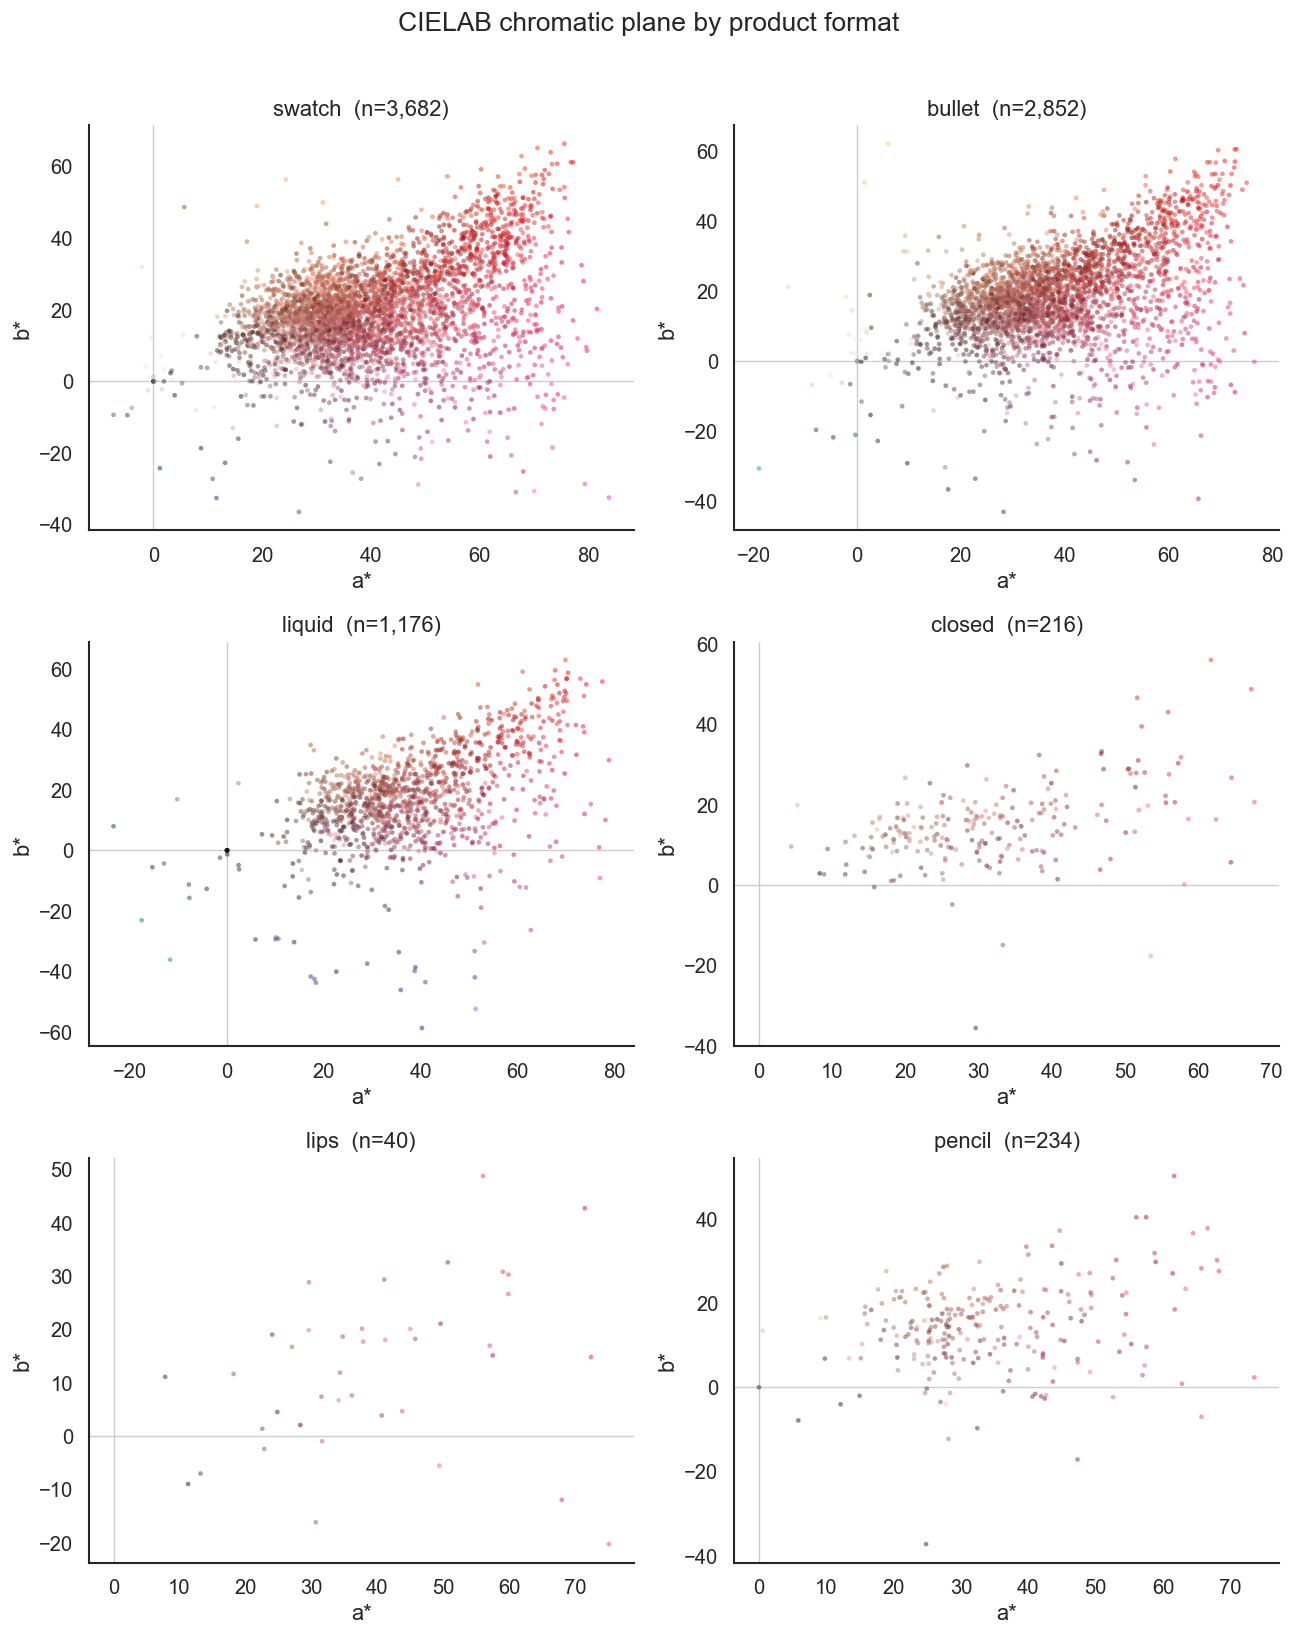

In [5]:
labels     = df['pred_label'].unique()
n_cols     = 2
n_rows     = int(np.ceil(len(labels) / n_cols))
fig, axes  = plt.subplots(n_rows, n_cols, figsize=(11, n_rows * 4.5), squeeze=False)

for ax, label in zip(axes.flat, labels):
    sub = df[df['pred_label'] == label]
    ax.scatter(sub['a'], sub['b'], c=sub['hex_color'],
               s=8, alpha=0.5, linewidths=0)
    ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
    ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
    ax.set_title(f'{label}  (n={len(sub):,})')
    ax.set_xlabel('a*')
    ax.set_ylabel('b*')
    sns.despine(ax=ax)

# Hide any unused subplots
for ax in axes.flat[len(labels):]:
    ax.set_visible(False)

fig.suptitle('CIELAB chromatic plane by product format', y=1.01)
plt.tight_layout()
plt.show()

## a\*–b\* scatter with GMM color group centroids

The 25 GMM groups are overlaid as larger circles. The centroid hex color is used to fill each marker, making it easy to see how the groups partition the color space.

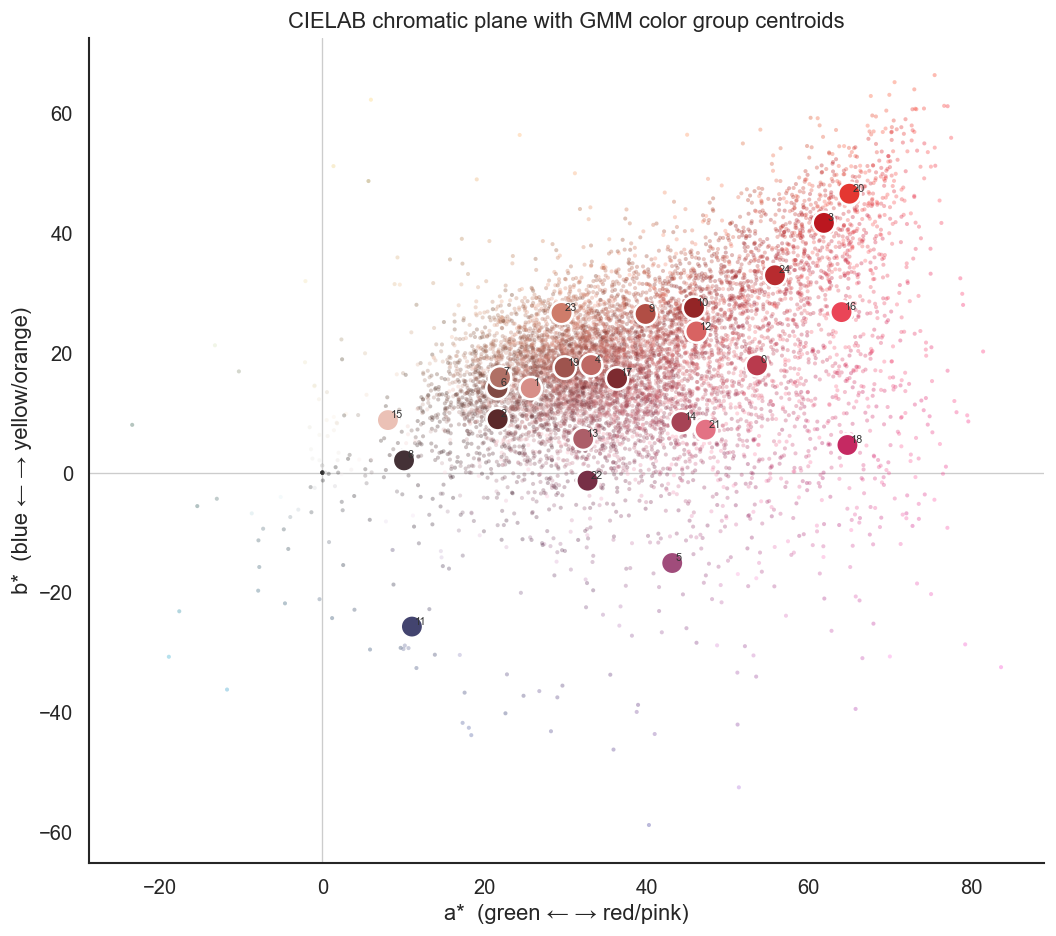

In [6]:
# Build group centroid table from the pipeline data
centroids = (
    df.groupby(['color_group', 'group_hex'])[['a', 'b']]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 8))

# All shades (small, semi-transparent)
ax.scatter(
    df['a'], df['b'],
    c=df['hex_color'],
    s=6, alpha=0.3, linewidths=0, zorder=1
)

# Group centroids (large, white border)
ax.scatter(
    centroids['a'], centroids['b'],
    c=centroids['group_hex'],
    s=180, linewidths=1.5, edgecolors='white', zorder=3
)

# Label group IDs
for _, row in centroids.iterrows():
    ax.text(row['a'] + 0.4, row['b'] + 0.4, str(int(row['color_group'])),
            fontsize=6.5, color='#333333', zorder=4)

ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
ax.set_xlabel('a*  (green ← → red/pink)')
ax.set_ylabel('b*  (blue ← → yellow/orange)')
ax.set_title('CIELAB chromatic plane with GMM color group centroids')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## L\*–C\* scatter (lightness vs chroma)

Chroma C\* = √(a\*² + b\*²). High chroma = vivid; low chroma = neutral/gray. This plot separates the vivid reds/pinks from the muted nudes/browns.

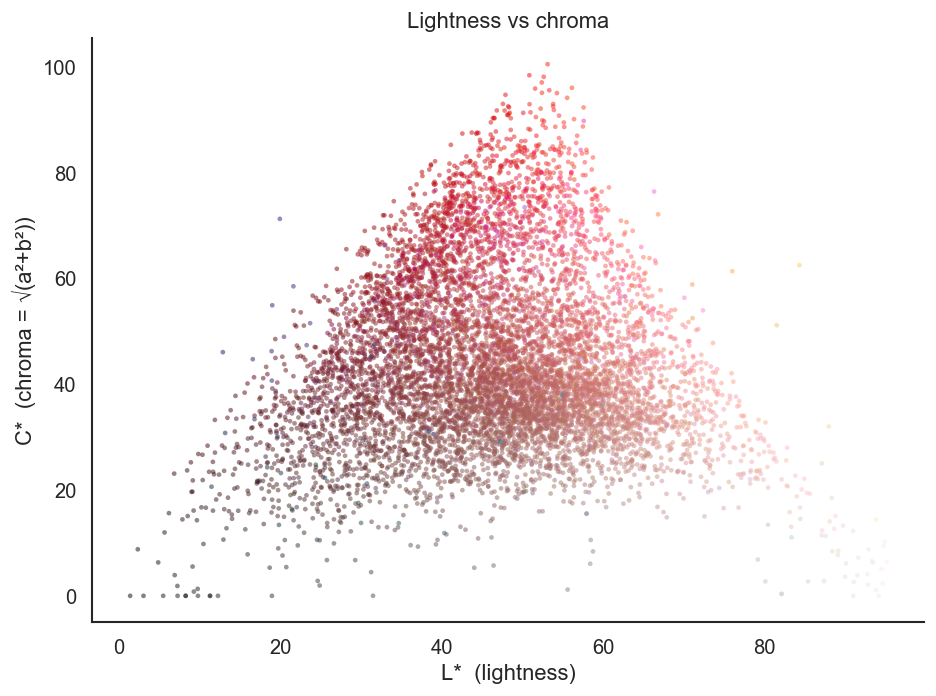

In [7]:
df['chroma'] = np.sqrt(df['a']**2 + df['b']**2)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df['L'], df['chroma'],
    c=df['hex_color'],
    s=8, alpha=0.5, linewidths=0
)

ax.set_xlabel('L*  (lightness)')
ax.set_ylabel('C*  (chroma = √(a²+b²))')
ax.set_title('Lightness vs chroma')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## a\*–b\* scatter by hue angle (undertone)

Hue angle h\* = arctan2(b\*, a\*) encodes undertone as a direction in the chromatic plane:
- **~0–30°**: cool reds / true reds
- **~30–60°**: warm reds / oranges
- **~60–90°**: orange / coral
- **~270–360°**: berries / purples / cool pinks

Points are colored by hue angle using a circular colormap (HSV). Low-chroma points (nudes, browns) still show their undertone bias even if the color looks muted.

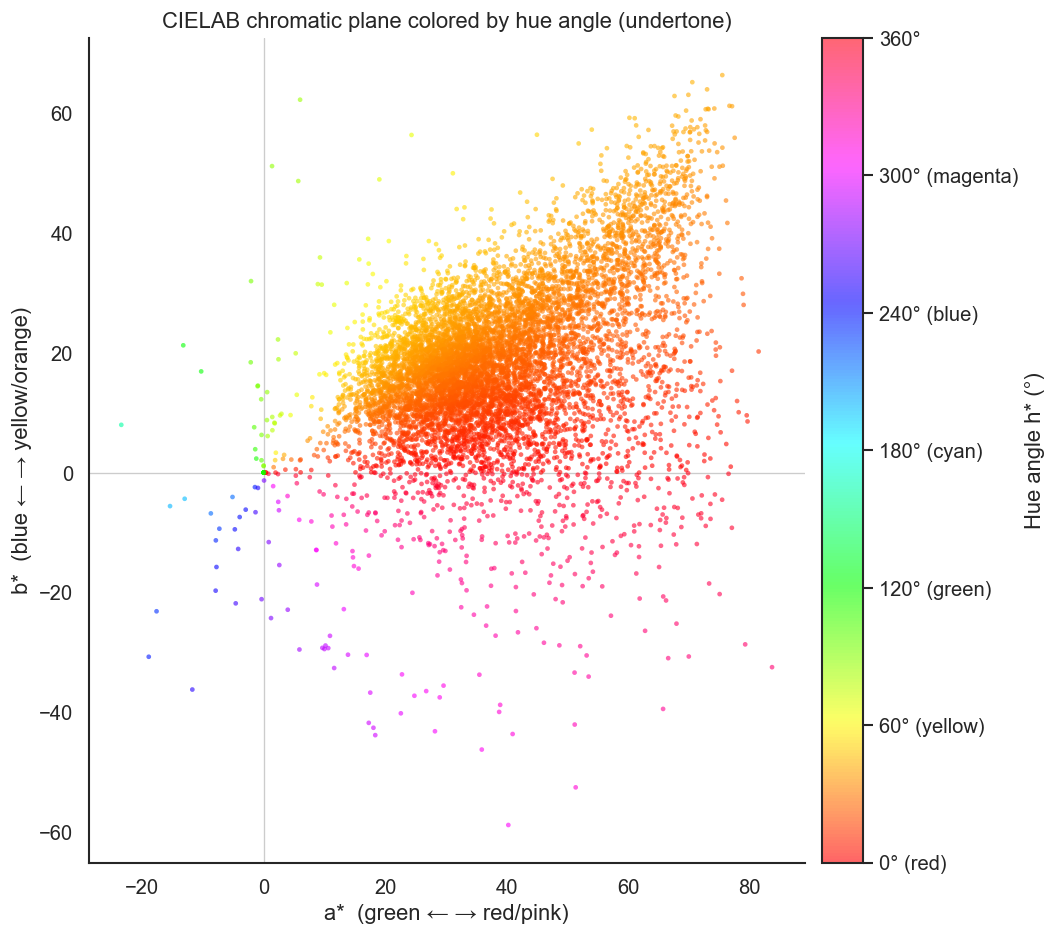

count    8200.0
mean       45.6
std        74.2
min         0.0
25%        20.4
50%        29.1
75%        36.2
max       360.0
Name: hue_angle, dtype: float64


In [8]:
df['chroma'] = np.sqrt(df['a']**2 + df['b']**2)
df['hue_angle'] = np.degrees(np.arctan2(df['b'], df['a'])) % 360

fig, ax = plt.subplots(figsize=(9, 8))

sc = ax.scatter(
    df['a'], df['b'],
    c=df['hue_angle'] / 360, cmap='hsv',
    s=8, alpha=0.6, linewidths=0
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Hue angle h* (°)')
cbar.set_ticks([0, 60/360, 120/360, 180/360, 240/360, 300/360, 1.0])
cbar.set_ticklabels(['0° (red)', '60° (yellow)', '120° (green)',
                     '180° (cyan)', '240° (blue)', '300° (magenta)', '360°'])

ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
ax.set_xlabel('a*  (green ← → red/pink)')
ax.set_ylabel('b*  (blue ← → yellow/orange)')
ax.set_title('CIELAB chromatic plane colored by hue angle (undertone)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(df['hue_angle'].describe().round(1))

## Hue angle distribution and undertone classification

Hue angle thresholds for undertone:
- **Cool**: h\* < 12° (cool reds) or 270–360° (berries/mauves)
- **Neutral**: 12° ≤ h\* < 28°
- **Warm**: 28° ≤ h\* < 270° (warm reds, oranges, corals)

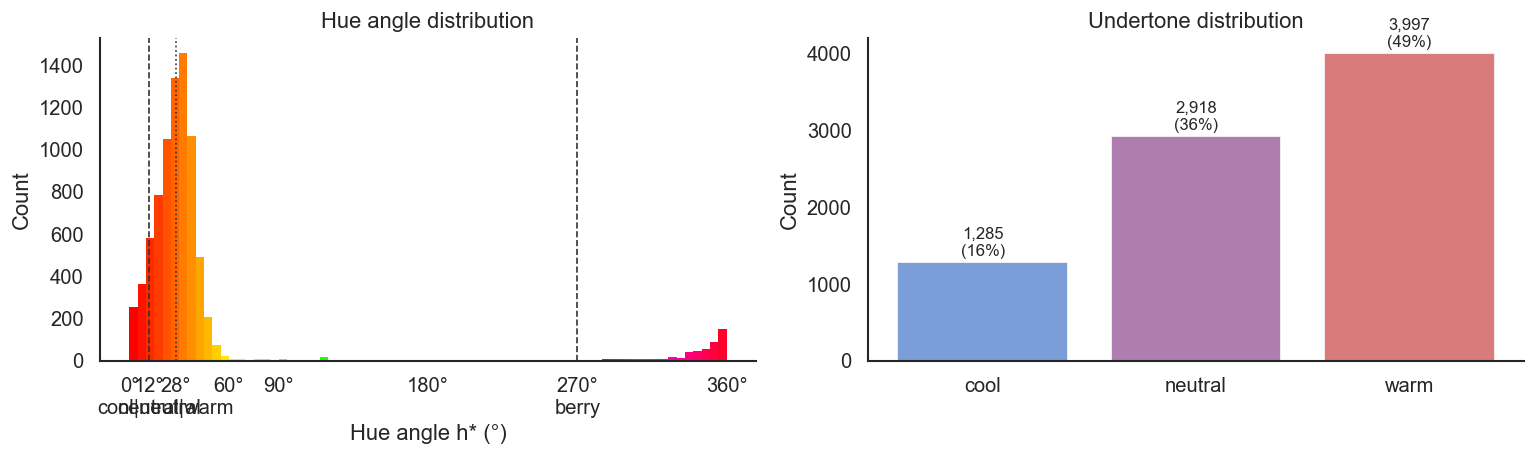

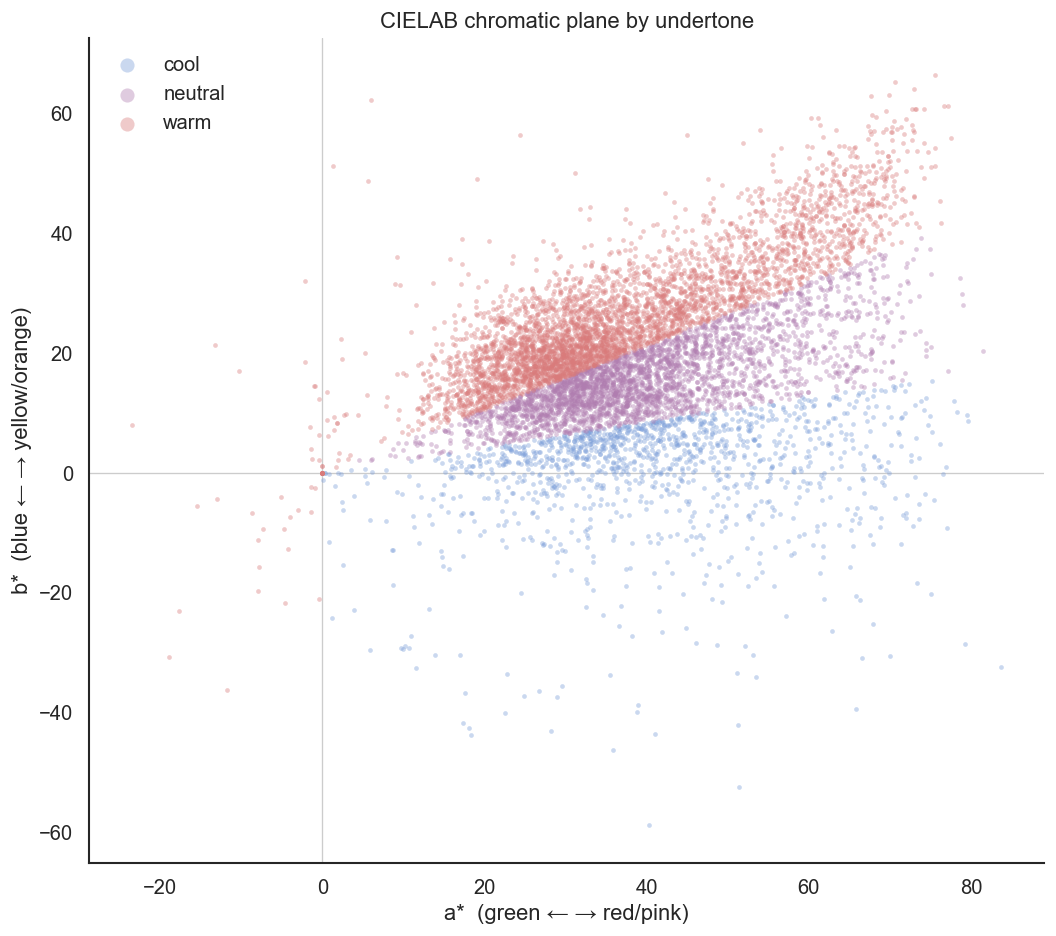

In [9]:
def classify_undertone(h):
    if h < 12 or h >= 270:
        return 'cool'
    elif h < 28:
        return 'neutral'
    else:
        return 'warm'

df['undertone'] = df['hue_angle'].apply(classify_undertone)

undertone_color = {'cool': '#7b9ed9', 'neutral': '#b07db0', 'warm': '#d97b7b'}

# ── Histogram colored by hue, with threshold lines ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
n, bins, patches = ax.hist(df['hue_angle'], bins=72, edgecolor='none')
for patch, left_edge in zip(patches, bins[:-1]):
    patch.set_facecolor(plt.cm.hsv(left_edge / 360))
ax.axvline(12,  color='#333333', lw=1, ls='--')
ax.axvline(28,  color='#333333', lw=1, ls=':')
ax.axvline(270, color='#333333', lw=1, ls='--')
ax.set_xlabel('Hue angle h* (°)')
ax.set_ylabel('Count')
ax.set_title('Hue angle distribution')
ax.set_xticks([0, 12, 28, 60, 90, 180, 270, 360])
ax.set_xticklabels(['0°', '12°\ncool|neutral', '28°\nneutral|warm',
                    '60°', '90°', '180°', '270°\nberry', '360°'])
sns.despine(ax=ax)

# ── Bar chart of undertone counts ─────────────────────────────────────────────
ax2 = axes[1]
counts = df['undertone'].value_counts().reindex(['cool', 'neutral', 'warm'])
bars = ax2.bar(counts.index, counts.values,
               color=[undertone_color[u] for u in counts.index], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
             f'{val:,}\n({val/len(df)*100:.0f}%)', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Count')
ax2.set_title('Undertone distribution')
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

# ── a*–b* scatter colored by undertone ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))

for undertone, group in df.groupby('undertone'):
    ax.scatter(group['a'], group['b'],
               c=undertone_color[undertone], label=undertone,
               s=8, alpha=0.4, linewidths=0)

ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
ax.set_xlabel('a*  (green ← → red/pink)')
ax.set_ylabel('b*  (blue ← → yellow/orange)')
ax.set_title('CIELAB chromatic plane by undertone')
ax.legend(markerscale=3, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Most common and most rare hues (density-based)

The 25 GMM color groups from notebook 08 turned out not to be a reliable
basis for this: `covariance_type='full'` lets a cluster's ellipsoid stretch
along one axis, so a rare cluster's own member can sit far from that
cluster's "representative" color and still belong to it (spot-checked
below — one rare-cluster member's own extracted color was ~18 ΔE76 from its
cluster's mean, a real outlier, not a rendering bug).

CIELAB's a\*-b\* plane is continuous, so instead of a forced hard-cluster
count, this estimates a smooth density surface over it (kernel density
estimate) and gives every product a **density percentile** — how crowded
its own exact spot in color space is relative to every other product.
"Common" hues sit in the busiest region by percentile; "rare" hues sit in
the emptiest. To pick concrete, sample-able regions for "top 5" a fine grid
bins occupancy over **L\*, a\*, and b\* together** (10 bins per axis) — an
a\*-b\*-only grid (bins on hue/chroma alone) let a single "hue region"
mix wildly different lightnesses (one bin spanned L\* 17.5-79.9 — a dark
maroon bullet and a light dusty-rose swatch landing in the same "common
hue" row, even though they don't look alike at all). Binning L\* too
bounds every region to at most a 19.0 ΔE\* diagonal, so the shown swatch
actually resembles its sampled products.

count    8200.0
mean       50.0
std        28.9
min         0.0
25%        25.0
50%        50.0
75%        75.0
max       100.0
Name: density_percentile, dtype: float64


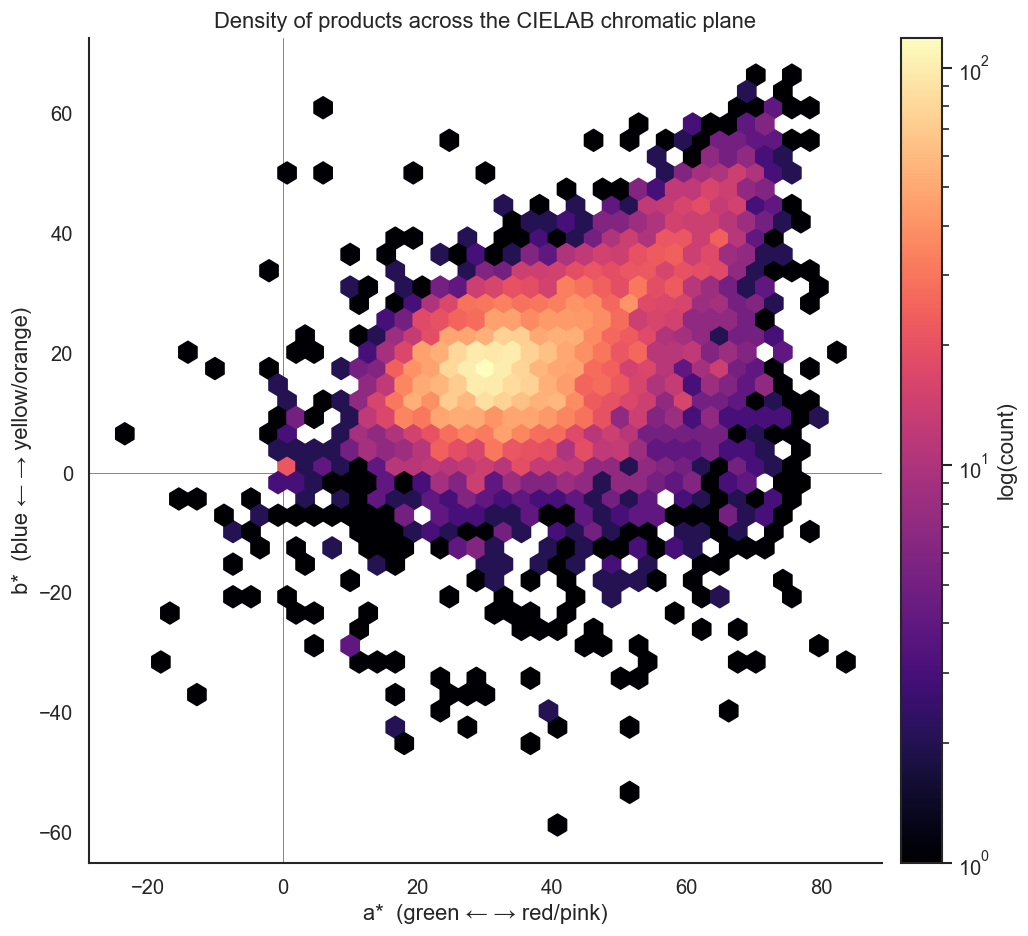

In [10]:
from scipy.stats import gaussian_kde

# Continuous density over the a*-b* plane -- each product's own density
# percentile is how crowded its exact color is relative to the rest of the
# catalog, without committing to a fixed number of hard clusters.
ab = df[['a', 'b']].values
kde = gaussian_kde(ab.T)
df['density'] = kde(ab.T)
df['density_percentile'] = df['density'].rank(pct=True) * 100

print(df['density_percentile'].describe().round(1))

# Visualize the density surface itself: hexbin occupancy under the same
# a*-b* scatter used throughout this notebook.
fig, ax = plt.subplots(figsize=(9, 8))
hb = ax.hexbin(df['a'], df['b'], gridsize=40, cmap='magma', mincnt=1, bins='log')
cbar = plt.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label('log(count)')
ax.axhline(0, color='#888888', lw=0.6, zorder=0)
ax.axvline(0, color='#888888', lw=0.6, zorder=0)
ax.set_xlabel('a*  (green \u2190 \u2192 red/pink)')
ax.set_ylabel('b*  (blue \u2190 \u2192 yellow/orange)')
ax.set_title('Density of products across the CIELAB chromatic plane')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

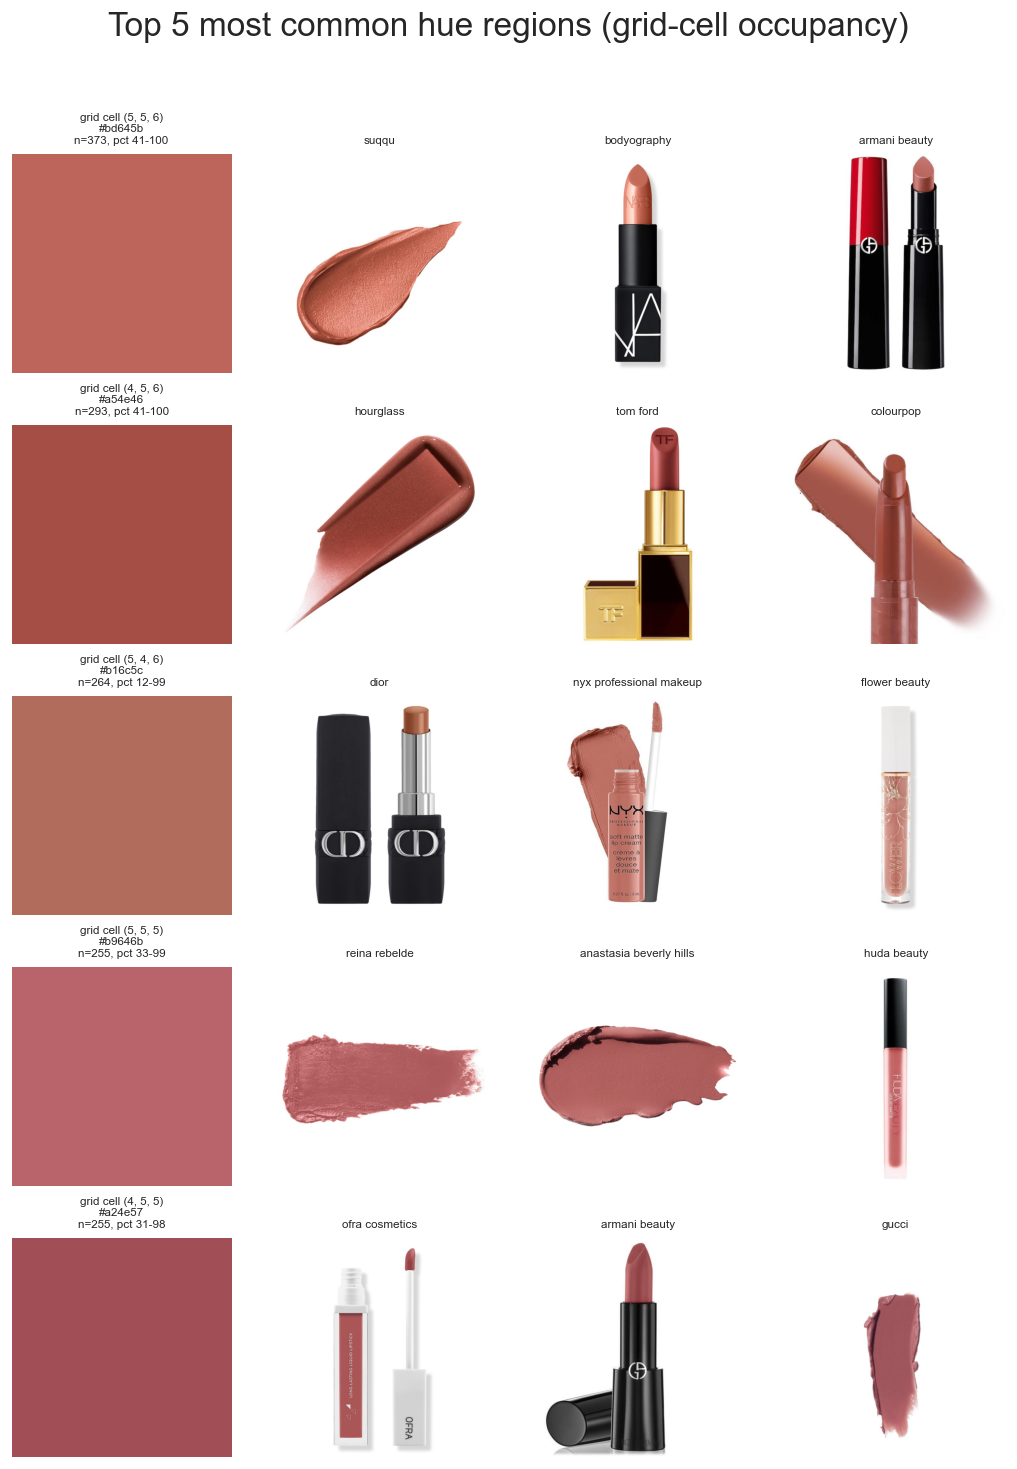

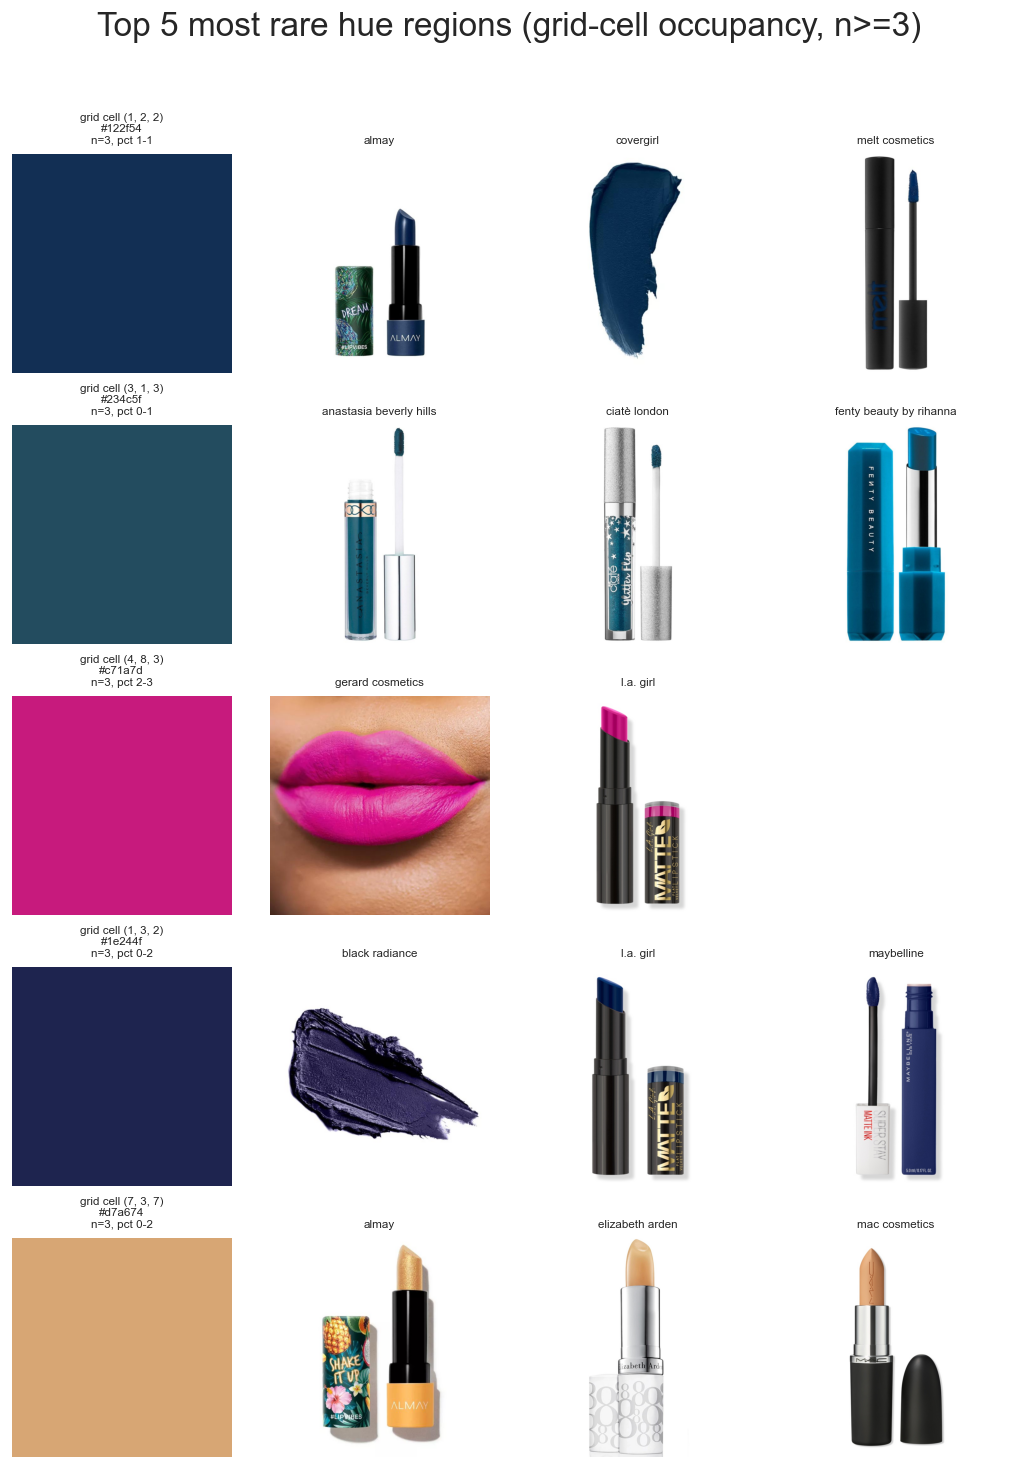

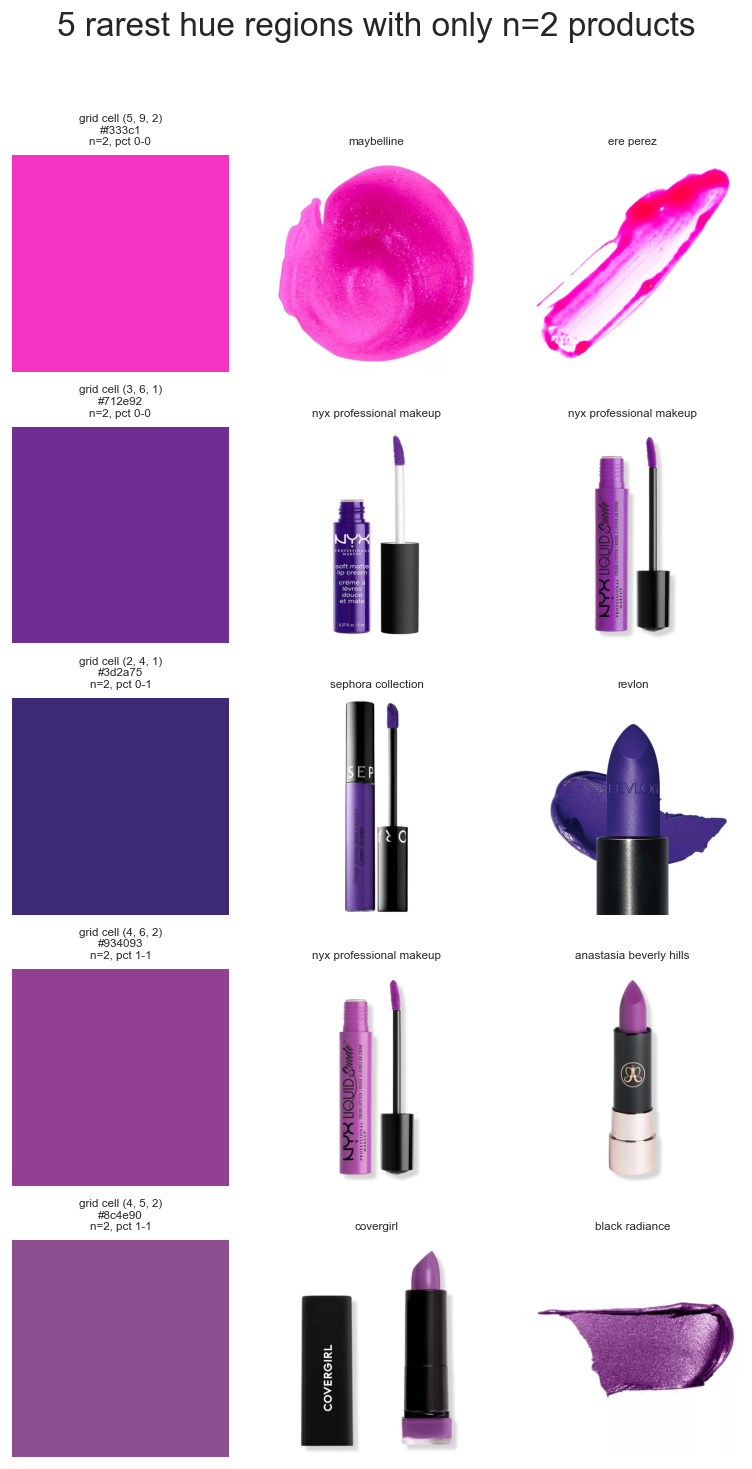

In [11]:
from PIL import Image
from skimage.color import lab2rgb
import matplotlib.colors as mcolors


def lab_to_hex(L, a, b):
    rgb = lab2rgb(np.array([[[L, a, b]]])).clip(0, 1)[0, 0]
    r, g, bch = (rgb * 255).round().astype(int)
    return f'#{r:02x}{g:02x}{bch:02x}'


# Grid-bin occupancy over L*, a*, b* together (not just a*-b*): fixed-size
# axis-aligned cells (not a fitted covariance shape) bound how different two
# products landing in the same cell can be, which is what let a GMM cluster
# member end up an outlier above -- and binning a*/b* alone still let a dark
# maroon and a light dusty-rose share one "hue region" (see markdown above).
#
# Wonderskin's "Wonder Blading" products are excluded here (not from the
# rest of the notebook): they're peel-off masques photographed as their
# applied blue/indigo gel, which then peels away to reveal an unrelated
# stain color -- the pipeline correctly extracts the photographed blue, but
# that blue isn't the product's actual lip color, so it doesn't belong in a
# "rare hue" analysis. With only 5 Wonderskin rows total (all blue/indigo),
# they were dense enough to fill 2 of the 5 rarest cells entirely on their
# own before this exclusion.
HUE_EXCLUDE_BRANDS = {'wonderskin'}
df_hue = df[~df['brand'].isin(HUE_EXCLUDE_BRANDS)].copy()

N_BINS = 10
RANDOM_SEED = 42
l_edges = np.linspace(df_hue['L'].min(), df_hue['L'].max(), N_BINS + 1)
a_edges = np.linspace(df_hue['a'].min(), df_hue['a'].max(), N_BINS + 1)
b_edges = np.linspace(df_hue['b'].min(), df_hue['b'].max(), N_BINS + 1)
df_hue['l_bin'] = pd.cut(df_hue['L'], l_edges, labels=False, include_lowest=True)
df_hue['a_bin'] = pd.cut(df_hue['a'], a_edges, labels=False, include_lowest=True)
df_hue['b_bin'] = pd.cut(df_hue['b'], b_edges, labels=False, include_lowest=True)
df_hue['grid_cell'] = list(zip(df_hue['l_bin'], df_hue['a_bin'], df_hue['b_bin']))

cell_counts = df_hue['grid_cell'].value_counts()
MIN_CELL_N = 3  # need at least a few products in a cell to sample from it
most_common_cells = cell_counts.head(5)
most_rare_cells = cell_counts[cell_counts >= MIN_CELL_N].tail(5).sort_values()

# Manual display-order override, by id, for specific grid cells -- picked by
# eye when the default (random_state=RANDOM_SEED) sample ordering puts a
# less representative product photo first (e.g. one whose color region is
# small/hard to see relative to the packaging in frame).
CELL_ORDER_OVERRIDES = {
    # Basma's own gloss color barely shows in its product photo (a red
    # compact + wand, not a clear color swatch) -- dropped rather than
    # reordered, leaving this rare region's other 2 real members.
    (4, 8, 3): [
        'lipstick__gerard_cosmetics__hydra_matte_liquid_lipstick__coachella',
        'lipstick__la_girl__matte_flat_velvet_lipstick__manic',
    ],
}


def show_region_samples(cells, counts, title, n_samples=5):
    fig, axes = plt.subplots(len(cells), n_samples + 1,
                              figsize=(2.2 * (n_samples + 1), 2.4 * len(cells)))
    for row, cell_key in enumerate(cells):
        grp = df_hue[df_hue['grid_cell'] == cell_key]
        mean_lab = grp[['L', 'a', 'b']].mean()
        hexcode = lab_to_hex(*mean_lab)
        pct_lo, pct_hi = grp['density_percentile'].min(), grp['density_percentile'].max()
        if cell_key in CELL_ORDER_OVERRIDES:
            order = CELL_ORDER_OVERRIDES[cell_key]
            sample = grp.set_index('id').loc[order].reset_index().head(n_samples)
        else:
            sample = grp.sample(min(n_samples, len(grp)), random_state=RANDOM_SEED)

        ax = axes[row, 0]
        ax.imshow([[mcolors.to_rgb(hexcode)]])
        ax.set_title(f'grid cell {cell_key}\n{hexcode}\n'
                     f'n={counts[cell_key]}, pct {pct_lo:.0f}-{pct_hi:.0f}', fontsize=7)
        ax.axis('off')

        for col in range(1, n_samples + 1):
            ax = axes[row, col]
            ax.axis('off')
            if col - 1 >= len(sample):
                continue
            r = sample.iloc[col - 1]
            try:
                img = Image.open(r['img_path']).convert('RGB')
                ax.imshow(img)
                ax.set_title(r['brand'] if pd.notna(r['brand']) else '', fontsize=7)
            except Exception:
                ax.text(0.5, 0.5, 'missing', ha='center', va='center', fontsize=7)

    fig.suptitle(title, y=1.02, fontsize=20)
    plt.tight_layout()
    plt.show()


show_region_samples(most_common_cells.index, most_common_cells,
                     'Top 5 most common hue regions (grid-cell occupancy)', n_samples=3)
show_region_samples(most_rare_cells.index, most_rare_cells,
                     'Top 5 most rare hue regions (grid-cell occupancy, n>=3)', n_samples=3)

# For comparison: cells with only 2 products (excluded above by MIN_CELL_N).
# All tie at count==2, so there's no count to rank by within this group --
# break the tie by each cell's mean density_percentile (still meaningful:
# the continuous KDE percentile doesn't collapse to ties the way the grid
# count does) and take the 5 lowest, i.e. the rarest of the rare-by-count.
mean_pct_by_cell = df_hue.groupby('grid_cell')['density_percentile'].mean()
rare_2_cells = cell_counts[cell_counts == 2]
rare_2_ranked = rare_2_cells.index.to_series().map(mean_pct_by_cell).sort_values()
most_rare_2_cells = rare_2_cells.loc[rare_2_ranked.index[:5]]

show_region_samples(most_rare_2_cells.index, most_rare_2_cells,
                     '5 rarest hue regions with only n=2 products', n_samples=2)